# **Day 78: Fairness, Bias and Responsible AI**
*Module 12 - Trustworthy ML and MLOps*

ML models make or support decisions about loans, jobs, medical care, disaster relief and land rights. A model can be accurate on average and still **systematically fail** for some groups or regions. In Earth observation, maps are often less accurate for smallholder farms, informal settlements, under-sampled regions and the Global South, and those errors flow into policy (crop insurance, flood compensation, deforestation enforcement).

> Models can be unfair when the data or design favours some groups. We measure fairness with group-wise metrics and reduce bias with better data, re-weighting or adjusted thresholds, and we document limitations openly.
>
> *Example:* A crop-insurance model trained mostly on large farms may wrongly reject valid claims from smallholders, whose fields look different from space.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score
rng = np.random.default_rng(78)

## **1. Sources of Bias**

| Stage | Bias | Example |
|---|---|---|
| Data collection | **Sampling / representation** | training points only near roads; few samples from hilly districts |
| Labels | **Label bias** | historical decisions (loan approvals) encode past discrimination; land-use labels from outdated maps |
| Measurement | **Measurement bias** | cloud cover hides some regions/seasons; sensors less accurate for small fields |
| Model | **Aggregation bias** | one model for heterogeneous populations fits the majority |
| Deployment | **Feedback loops / misuse** | predictions used outside the intended context; decisions change future data |

## **2. A Case Study: Crop-Loss Compensation Claims**
A model predicts whether a farmer's crop-loss claim is valid, using satellite-derived NDVI drop, rainfall deficit and field size. Two groups: **large farms** (well represented, large fields, clean satellite signal) and **smallholders** (under-represented, small fields mixed with neighbours, noisier signal).

In [2]:
def make_farms(n_large, n_small, seed):
    r = np.random.default_rng(seed); rows = []
    for group, n, noise in [("large", n_large, 0.05), ("smallholder", n_small, 0.18)]:
        loss = r.random(n) < 0.3                                                 # true crop loss
        ndvi_drop = np.where(loss, r.normal(0.25, 0.08, n), r.normal(0.05, 0.05, n)) + r.normal(0, noise, n)   # mixed pixels add noise
        rain_def = np.where(loss, r.normal(30, 12, n), r.normal(10, 10, n))
        field_ha = r.lognormal(2.0, 0.4, n) if group == "large" else r.lognormal(-0.3, 0.4, n)
        rows.append(pd.DataFrame({"group": group, "ndvi_drop": ndvi_drop, "rain_deficit_pct": rain_def, "field_ha": field_ha, "loss": loss.astype(int)}))
    return pd.concat(rows, ignore_index=True)
df = make_farms(4000, 600, 1)                                                     # smallholders under-represented in training
test = make_farms(2000, 2000, 2)                                                  # but half of the real population
features = ["ndvi_drop", "rain_deficit_pct", "field_ha"]
model = HistGradientBoostingClassifier(random_state=0).fit(df[features], df.loss)
test["p"] = model.predict_proba(test[features])[:, 1]; test["pred"] = (test.p >= 0.5).astype(int)
print(f"overall test accuracy {accuracy_score(test.loss, test.pred):.3f}")

overall test accuracy 0.889


## **3. Disaggregated Evaluation**
Always report metrics **per group** (and per region / class / season in RS). An overall score hides who bears the errors.

In [3]:
def group_report(d, pred_col="pred", prob_col="p"):
    rows = {}
    for g, s in d.groupby("group"):
        rows[g] = {"n": len(s), "accuracy": accuracy_score(s.loss, s[pred_col]), "approval rate (P(pred=1))": s[pred_col].mean(),
                   "TPR / recall (valid claims paid)": recall_score(s.loss, s[pred_col]), "FPR (invalid claims paid)": s[pred_col][s.loss == 0].mean(),
                   "precision": precision_score(s.loss, s[pred_col], zero_division=0), "ROC-AUC": roc_auc_score(s.loss, s[prob_col])}
    return pd.DataFrame(rows).T.round(3)
group_report(test)

,n,accuracy,approval rate (P(pred=1)),TPR / recall (valid claims paid),FPR (invalid claims paid),precision,ROC-AUC
large,2000.0,0.936,0.292,0.864,0.031,0.926,0.976
smallholder,2000.0,0.842,0.308,0.750,0.118,0.732,0.909


Smallholders with **genuine** losses are paid less often (lower TPR): the model is worse for exactly the group that is most vulnerable and was under-sampled.

## **4. Fairness Criteria**
Let $A$ be the group, $Y$ the truth, $\hat Y$ the decision, $S$ the score.

| Criterion | Requirement | Meaning here |
|---|---|---|
| **Demographic parity** | $P(\hat Y=1\mid A=a)$ equal | same payout rate for both groups |
| **Equal opportunity** | $P(\hat Y=1\mid Y=1, A=a)$ equal | genuine losses equally likely to be paid (equal TPR) |
| **Equalised odds** | equal TPR **and** FPR | errors of both kinds equally distributed |
| **Calibration within groups** | $P(Y=1\mid S=s, A=a) = s$ | a score of 0.7 means the same for everyone |

**Impossibility** (Kleinberg et al., 2017; Chouldechova, 2017): when base rates differ between groups, calibration and equalised odds cannot both hold (except for a perfect predictor). Choosing a criterion is a **value judgement** that should involve stakeholders.

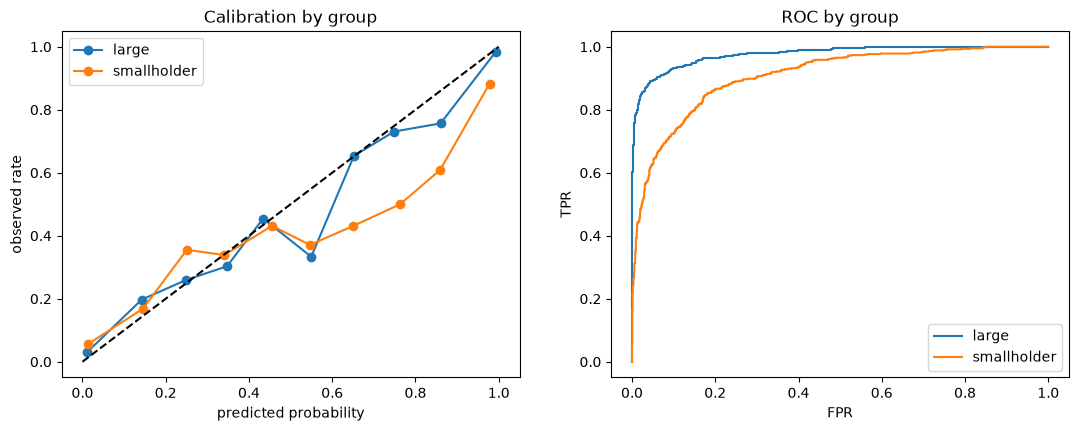

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for g, s in test.groupby("group"):
    bins = pd.cut(s.p, np.linspace(0, 1, 11)); cal = s.groupby(bins, observed=True).agg(p=("p", "mean"), y=("loss", "mean"))
    axes[0].plot(cal.p, cal.y, "o-", label=g)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(s.loss, s.p); axes[1].plot(fpr, tpr, label=g)
axes[0].plot([0, 1], [0, 1], "k--"); axes[0].set(xlabel="predicted probability", ylabel="observed rate", title="Calibration by group"); axes[0].legend()
axes[1].set(xlabel="FPR", ylabel="TPR", title="ROC by group"); axes[1].legend(); plt.show()

## **5. Mitigation**

### (a) Better data: the most effective fix
Collect more representative samples (stratified by group/region, Day 88) and better features for the disadvantaged group (e.g. higher-resolution imagery for small fields).

In [5]:
df_bal = make_farms(4000, 4000, 3)
m_bal = HistGradientBoostingClassifier(random_state=0).fit(df_bal[features], df_bal.loss)
t2 = test.copy(); t2["p"] = m_bal.predict_proba(t2[features])[:, 1]; t2["pred"] = (t2.p >= 0.5).astype(int)
print("After collecting representative smallholder data:"); print(group_report(t2))

After collecting representative smallholder data:
                  n  accuracy  approval rate (P(pred=1))  \
large        2000.0     0.940                      0.290   
smallholder  2000.0     0.864                      0.269   

             TPR / recall (valid claims paid)  FPR (invalid claims paid)  \
large                                   0.866                      0.027   
smallholder                             0.722                      0.074   

             precision  ROC-AUC  
large            0.936    0.976  
smallholder      0.807    0.918  


### (b) Re-weighting (in-processing)
Give under-represented groups more weight in the loss (Kamiran & Calders, 2012).

In [6]:
w = df.group.map(1 / df.group.value_counts(normalize=True))
m_w = HistGradientBoostingClassifier(random_state=0).fit(df[features], df.loss, sample_weight=w)
t3 = test.copy(); t3["p"] = m_w.predict_proba(t3[features])[:, 1]; t3["pred"] = (t3.p >= 0.5).astype(int)
print("Re-weighted training:"); print(group_report(t3)[["accuracy", "TPR / recall (valid claims paid)", "FPR (invalid claims paid)"]])

Re-weighted training:
             accuracy  TPR / recall (valid claims paid)  \
large           0.939                             0.867   
smallholder     0.848                             0.764   

             FPR (invalid claims paid)  
large                            0.028  
smallholder                      0.116  


### (c) Group-specific thresholds (post-processing for equal opportunity)
Choose a threshold per group so that TPR is equal (Hardt et al., 2016). Note the trade-off: it raises false positives for that group, and it requires knowing group membership at decision time (sometimes legally restricted).

In [7]:
target_tpr = 0.9
thr = {g: np.quantile(s.p[s.loss == 1], 1 - target_tpr) for g, s in test.groupby("group")}   # in practice: choose on validation data
t4 = test.copy(); t4["pred"] = (t4.p >= t4.group.map(thr)).astype(int)
print("thresholds:", {k: round(float(v), 3) for k, v in thr.items()}); print(group_report(t4)[["accuracy", "TPR / recall (valid claims paid)", "FPR (invalid claims paid)"]])

thresholds: {'large': 0.28, 'smallholder': 0.075}
             accuracy  TPR / recall (valid claims paid)  \
large           0.927                             0.899   
smallholder     0.763                             0.900   

             FPR (invalid claims paid)  
large                            0.060  
smallholder                      0.296  


## **6. Documentation: Datasheets and Model Cards**
**Datasheets for datasets** (Gebru et al., 2021) and **model cards** (Mitchell et al., 2019) record what data were used, who/where they represent, intended use, out-of-scope use, disaggregated performance, and known limitations. Many journals and agencies now expect them.

In [8]:
model_card = f"""
MODEL CARD: crop-loss claim triage model (teaching example)
Intended use      : prioritise field verification of claims; NOT for automatic rejection
Training data     : 4,000 large-farm and 600 smallholder claims (synthetic); smallholders under-represented
Inputs            : Sentinel-2 NDVI drop, rainfall deficit (%), field area (ha)
Performance (test): overall accuracy {accuracy_score(test.loss, test.pred):.3f}
                    TPR large {recall_score(test.loss[test.group == 'large'], test.pred[test.group == 'large']):.3f} | TPR smallholder {recall_score(test.loss[test.group == 'smallholder'], test.pred[test.group == 'smallholder']):.3f}
Known limitations : mixed pixels for fields < 1 ha at 10 m resolution; lower recall for smallholders
Recommendations   : collect stratified smallholder samples; use higher-resolution imagery for small fields;
                    human review of all predicted rejections
"""
print(model_card)


MODEL CARD: crop-loss claim triage model (teaching example)
Intended use      : prioritise field verification of claims; NOT for automatic rejection
Training data     : 4,000 large-farm and 600 smallholder claims (synthetic); smallholders under-represented
Inputs            : Sentinel-2 NDVI drop, rainfall deficit (%), field area (ha)
Performance (test): overall accuracy 0.889
                    TPR large 0.864 | TPR smallholder 0.750
Known limitations : mixed pixels for fields < 1 ha at 10 m resolution; lower recall for smallholders
Recommendations   : collect stratified smallholder samples; use higher-resolution imagery for small fields;
                    human review of all predicted rejections



# **Part 2: Going Deeper - Spatial Fairness and Proxies**

### Spatial fairness in remote sensing
Global land-cover and building-footprint products are measurably less accurate in some regions (e.g. informal settlements, smallholder agriculture, tropical cloudy areas). Report accuracy **per region / administrative unit / landscape type**, and test spatial transfer explicitly (Days 79, 88). A map that is "95% accurate" globally can be 70% accurate where decisions matter most.

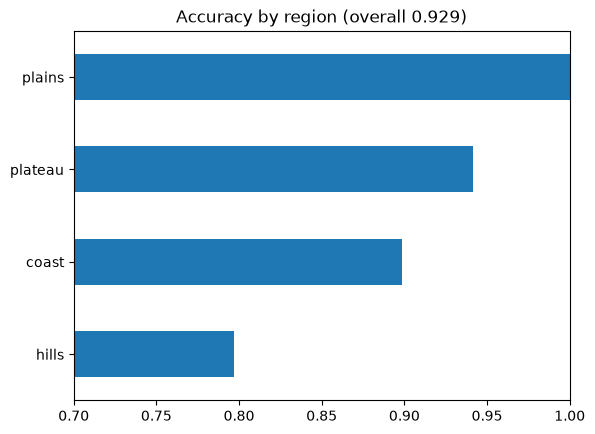

In [9]:
regions = rng.choice(["plains", "plateau", "hills", "coast"], len(test), p=[0.4, 0.25, 0.2, 0.15])
region_noise = pd.Series(regions).map({"plains": 0.0, "plateau": 0.05, "hills": 0.2, "coast": 0.1}).values      # e.g. terrain shadow, cloud
pred_reg = np.where(rng.random(len(test)) < region_noise, 1 - test.loss.values, test.loss.values)
acc_reg = pd.Series(pred_reg == test.loss.values).groupby(regions).mean().sort_values()
acc_reg.plot.barh(title=f"Accuracy by region (overall {np.mean(pred_reg == test.loss.values):.3f})"); plt.xlim(0.7, 1); plt.show()

### Removing the sensitive attribute is not enough
Even without the group label, the model can infer it from **proxies** (here, field size almost perfectly identifies smallholders; in other settings postcode or language). "Fairness through unawareness" usually fails; measure outcomes instead. Causal reasoning (which paths from the attribute to the decision are legitimate?) is needed to decide what is fair (Kusner et al., 2017).

In [10]:
proxy_auc = roc_auc_score((test.group == "smallholder").astype(int), -test.field_ha)
print(f"field size alone identifies smallholders with ROC-AUC = {proxy_auc:.3f}: the model 'knows' the group without being told")

field size alone identifies smallholders with ROC-AUC = 1.000: the model 'knows' the group without being told


## **Practice Problems**
1. Compute the demographic-parity difference and equal-opportunity difference for the original model and the three mitigated versions.
2. Remove `field_ha` from the features. Does the TPR gap shrink? What happens to overall accuracy?
3. Write a short datasheet (motivation, composition, collection process, intended uses) for a land-cover training dataset we might build.
4. *(Advanced)* Show the impossibility result numerically: with different base rates in two groups, adjust thresholds to equalise TPR and FPR and then check calibration within groups.

In [11]:
# Solution 1
def gaps(d):
    s = {g: x for g, x in d.groupby("group")}
    dp = s["large"].pred.mean() - s["smallholder"].pred.mean()
    eo = recall_score(s["large"].loss, s["large"].pred) - recall_score(s["smallholder"].loss, s["smallholder"].pred)
    return {"demographic parity diff": round(float(dp), 3), "equal opportunity diff (TPR gap)": round(float(eo), 3), "accuracy": round(accuracy_score(d.loss, d.pred), 3)}
print(pd.DataFrame({"original": gaps(test), "representative data": gaps(t2), "re-weighting": gaps(t3), "group thresholds": gaps(t4)}).T)
# Solution 2
m_nf = HistGradientBoostingClassifier(random_state=0).fit(df[["ndvi_drop", "rain_deficit_pct"]], df.loss)
t5 = test.copy(); t5["p"] = m_nf.predict_proba(t5[["ndvi_drop", "rain_deficit_pct"]])[:, 1]; t5["pred"] = (t5.p >= 0.5).astype(int)
print("without field size:", gaps(t5))

                     demographic parity diff  \
original                              -0.016   
representative data                    0.020   
re-weighting                          -0.020   
group thresholds                      -0.154   

                     equal opportunity diff (TPR gap)  accuracy  
original                                        0.114     0.889  
representative data                             0.144     0.902  
re-weighting                                    0.104     0.893  
group thresholds                               -0.001     0.845  


without field size: {'demographic parity diff': -0.081, 'equal opportunity diff (TPR gap)': 0.058, 'accuracy': 0.873}


Problems 3 and 4 are **open exercises**. Problem 3 is a writing task: use the Gebru et al. *Datasheets for Datasets* questions. For Problem 4, reuse the threshold-search code from Section 4 on two groups with different base rates, then plot a reliability curve for each group.

## **Key References**
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press (fairmlbook.org).
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *NeurIPS 29*.
- Kleinberg, J., Mullainathan, S., & Raghavan, M. (2017). Inherent trade-offs in the fair determination of risk scores. *ITCS 2017*.
- Chouldechova, A. (2017). Fair prediction with disparate impact: A study of bias in recidivism prediction instruments. *Big Data*, 5(2), 153-163.
- Mitchell, M. et al. (2019). Model cards for model reporting. *FAT* 2019*.
- Gebru, T. et al. (2021). Datasheets for datasets. *Communications of the ACM*, 64(12), 86-92.
- Kamiran, F., & Calders, T. (2012). Data preprocessing techniques for classification without discrimination. *Knowledge and Information Systems*, 33(1), 1-33.
- Kusner, M. J., Loftus, J., Russell, C., & Silva, R. (2017). Counterfactual fairness. *NeurIPS 30*.